In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подключаемся к базе SQLite
db_path = "../db/wikipedia.db"

## 1.1. Количество автомобилей в базе

In [36]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
  num_vehicles = len(df)
  print(f"Общее количество автомобилей в базе: {num_vehicles}")

Общее количество автомобилей в базе: 9581


## 1.2. Распределение моделей по годам начала производства

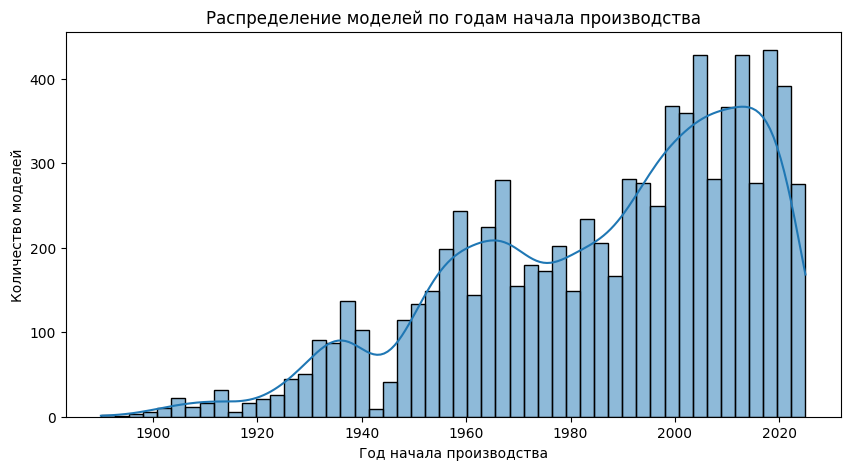

In [39]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
  plt.figure(figsize=(10, 5))
  sns.histplot(df['production_start_year'].dropna(), bins=50, kde=True)
  #plt.xlim(1900, 2025)  # Устанавливаем границы оси X
  plt.xlabel("Год начала производства")
  plt.ylabel("Количество моделей")
  plt.title("Распределение моделей по годам начала производства")
  plt.show()

## 1.3. Распределение моделей по годам окончания производства

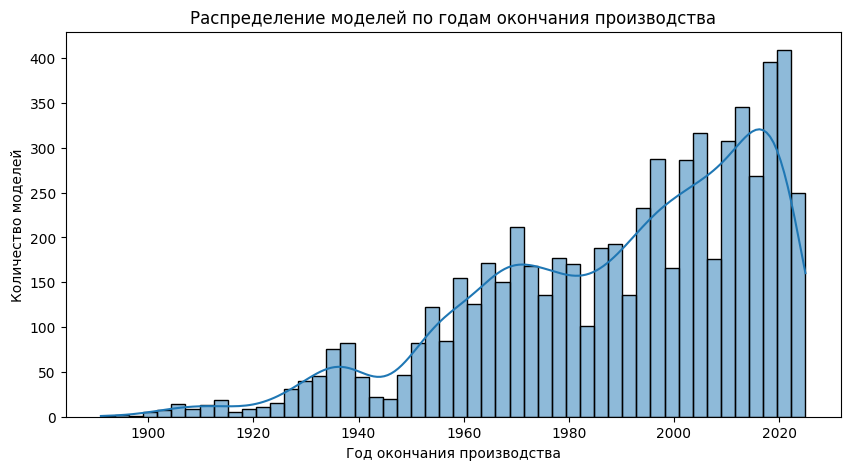

In [38]:
with sqlite3.connect(db_path) as conn:
  # Загружаем данные
  query = "SELECT id, production_start_year, production_end_year, vehicle_class, body_style FROM vehicles"
  df = pd.read_sql(query, conn)
plt.figure(figsize=(10, 5))
sns.histplot(df['production_end_year'].dropna(), bins=50, kde=True)
plt.xlabel("Год окончания производства")
plt.ylabel("Количество моделей")
plt.title("Распределение моделей по годам окончания производства")
plt.show()

## 1.4. Количество моделей по классам 

Всего количество классов автомобилей: 579


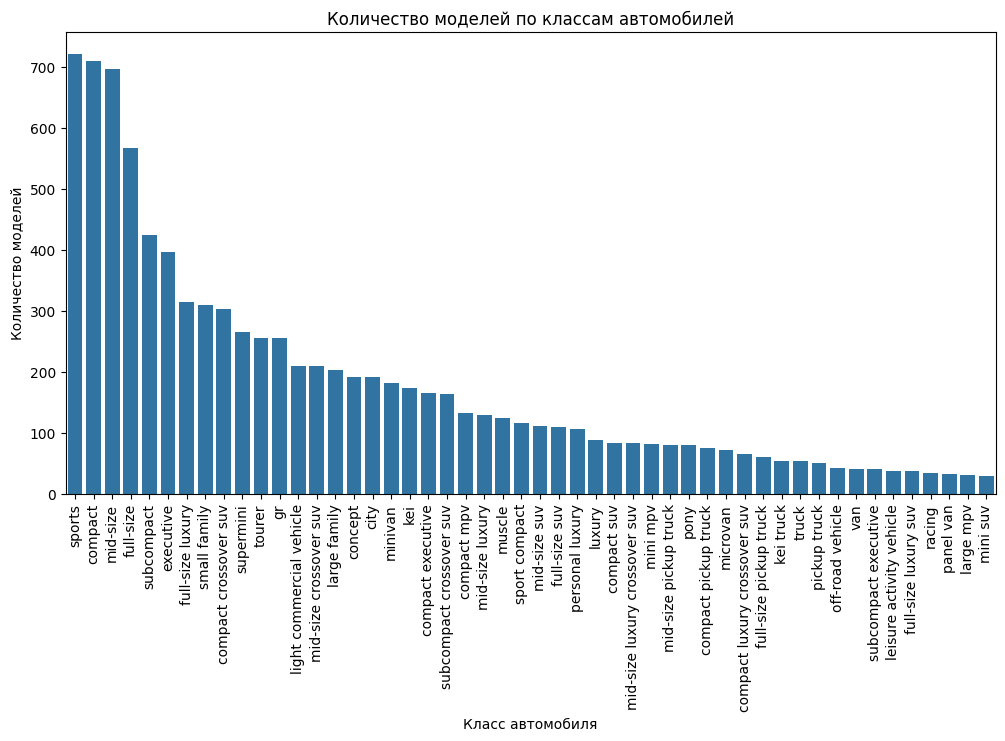

In [34]:
with sqlite3.connect(db_path) as conn:
  df = pd.read_sql("SELECT vehicle_class FROM vehicles", conn)

# Убираем NaN (если есть)
df = df.dropna()

# Разбиваем vehicle_class по `;` и преобразуем в длинный список
all_classes = df['vehicle_class'].str.replace('car', '').str.split(';').explode().str.strip()

# Считаем, сколько раз встречается каждый класс
class_counts = all_classes.value_counts()
print(f"Всего количество классов автомобилей: {len(class_counts.index)}")

# Только 10 самых частых классов
top_classes = class_counts.head(50)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=top_classes.index, y=top_classes.values)
plt.xticks(rotation=90)  # Поворачиваем подписи, если их много
plt.xlabel("Класс автомобиля")
plt.ylabel("Количество моделей")
plt.title("Количество моделей по классам автомобилей")
plt.show()

## 1.5. Количество моделей по типам кузова

Всего количество типов кузова: 1499


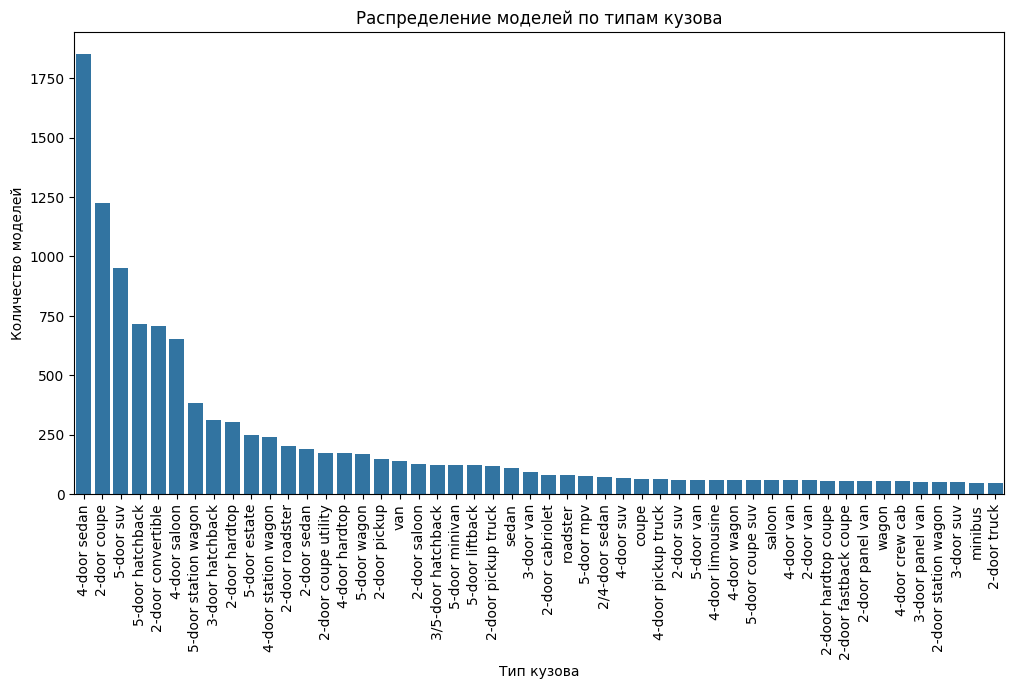

In [35]:
with sqlite3.connect(db_path) as conn:
  df = pd.read_sql("SELECT body_style FROM vehicles", conn)

# Убираем NaN (если есть)
df = df.dropna()

# Разбиваем vehicle_class по `;` и преобразуем в длинный список
all_body_style = df['body_style'].str.split(';').explode().str.strip()

# Считаем, сколько раз встречается каждый тип кузова
body_style_counts = all_body_style.value_counts()
print(f"Всего количество типов кузова: {len(body_style_counts.index)}")

# Только 10 самых частых классов
top_body_style = body_style_counts.head(50)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(x=top_body_style.index, y=top_body_style.values)
plt.xticks(rotation=90)  # Поворачиваем подписи, если их много
plt.xlabel("Тип кузова")
plt.ylabel("Количество моделей")
plt.title("Распределение моделей по типам кузова")
plt.show()

2.1. Количество автомобилей с разными типами топлива

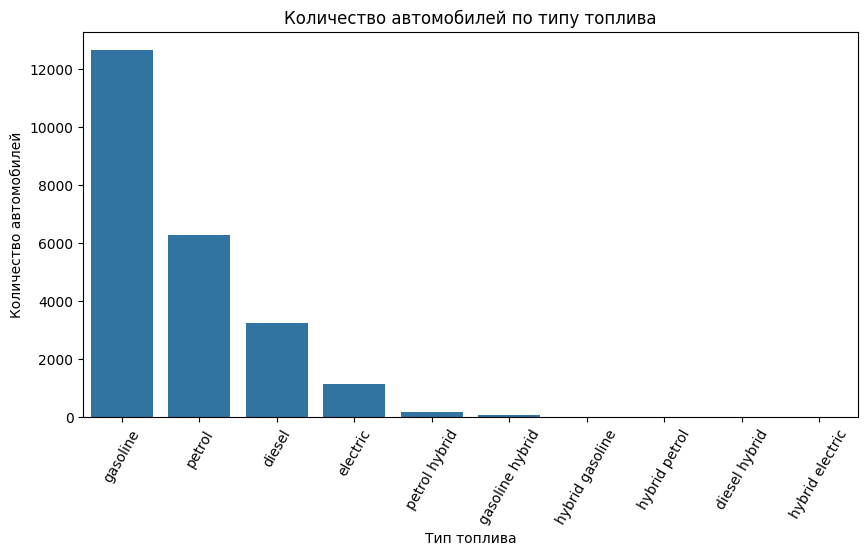

In [43]:
# Загружаем данные
with sqlite3.connect(db_path) as conn:
    df_engines = pd.read_sql("SELECT type_fuel FROM engines", conn)
# Убираем NaN
df_engines = df_engines.dropna()
# Считаем количество автомобилей для каждого типа топлива
fuel_counts = df_engines['type_fuel'].value_counts()
# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values)
plt.xlabel("Тип топлива")
plt.ylabel("Количество автомобилей")
plt.title("Количество автомобилей по типу топлива")
plt.xticks(rotation=60)  # Поворачиваем подписи, если их много
plt.show()